In [60]:
# Penguins Body Mass Regression
 
import joblib
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
 
# 1. Load dataset
df = pd.read_csv("C:/data/GitHub/BZIA_VM/DS/sk-learn_2026/data/synthetic_penguins_500.csv")
X = df.drop('body_mass_g', axis=1)
 
# 2. Load the saved pipeline
loaded_pipeline = joblib.load('C:/data/GitHub/BZIA_VM/DS/sk-learn_2026/data/Pipeline/penguin_bodymass_regressionIII.joblib')

In [61]:
X.iloc[[151, 200,28,300]]

,species,island,sex,year,bill_length_mm,bill_depth_mm,flipper_length_mm
151,Adelie,Biscoe,female,2009,32.879887,19.815344,179.980614
200,Chinstrap,Biscoe,female,2008,51.165938,17.442734,205.631349
28,Chinstrap,Dream,female,2009,46.163073,16.501003,192.198861
300,Adelie,Biscoe,female,2008,48.861182,19.020510,210.639468


In [62]:
# 3. Use it directly for prediction
sample = X #.iloc[[151, 200,28,300]]   # example row
y_hat = loaded_pipeline.predict(sample)

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [63]:
df['y_hat'] = y_hat
df[['body_mass_g', 'y_hat']]

,body_mass_g,y_hat
0,4825.559793,3298.096799
1,3467.839740,3862.783460
2,4640.443781,3346.541110
3,5172.165989,5064.659324
4,4334.849972,4138.019875
...,...,...
495,4139.246148,3114.119431
496,4883.623673,4070.180718
497,4189.681120,4904.934465
498,3532.865354,3736.791281


In [64]:
loaded_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('linreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [65]:
df.iloc[[151, 200,28,300]]

,species,island,sex,year,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,y_hat
151,Adelie,Biscoe,female,2009,32.879887,19.815344,179.980614,3197.865616,3363.450609
200,Chinstrap,Biscoe,female,2008,51.165938,17.442734,205.631349,3941.049637,3742.082631
28,Chinstrap,Dream,female,2009,46.163073,16.501003,192.198861,3767.420062,3292.551030
300,Adelie,Biscoe,female,2008,48.861182,19.020510,210.639468,5009.687023,4216.260784


In [66]:
r2_score(df['body_mass_g'], y_hat)

-0.10776910663150985

<Axes: xlabel='body_mass_g', ylabel='y_hat'>

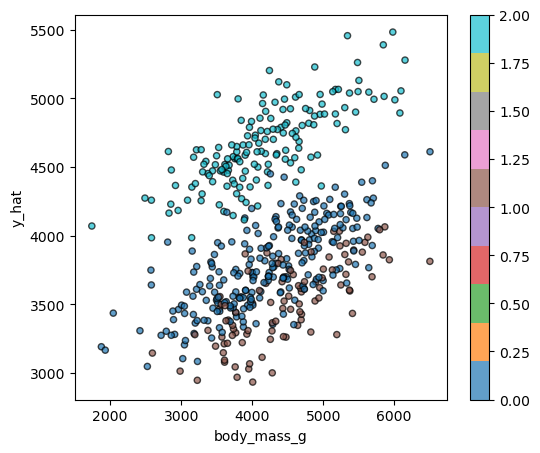

In [67]:
df[['body_mass_g', 'y_hat', 'species']].plot.scatter(
    x = 'body_mass_g',
    y = 'y_hat',
    c=df['species'].astype('category').cat.codes,  # numeric codes for categories
    cmap='tab10',          # a valid colormap name
    figsize = (6,5),
    alpha = 0.7,
    edgecolor = 'k' 
)

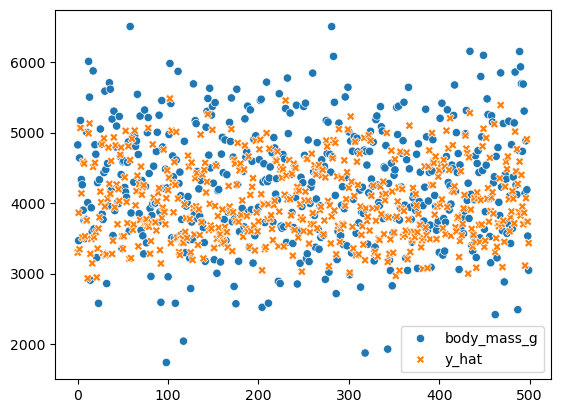

In [68]:
df2 = df[['body_mass_g', 'y_hat', 'species']]
sns.scatterplot(data=df2);

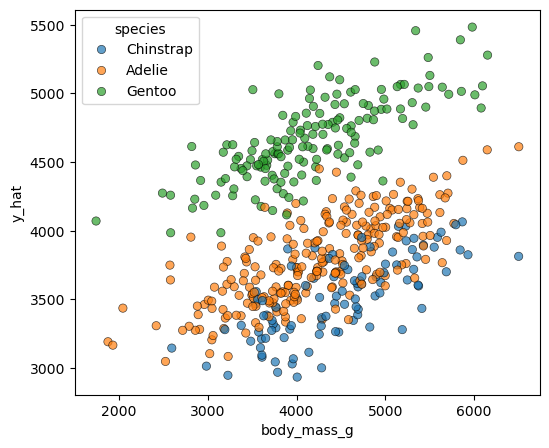

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x='body_mass_g',
    y='y_hat',
    hue='species',          # categorical hue handled automatically
    palette='tab10',
    alpha=0.7,
    edgecolor='k'
)
plt.legend(title='species')
plt.show()